# 6 Unsupervised Models

Using the same dataset, we try to cluster players into injury risk archetypes such as durable young players, high-mileage veterans, or injury-prone stars using unsupervised clustering techniques. Features will be standardized for distance-based clustering.

We will apply K-Means for interpretability and Hierarchical Clustering to examine groupings at different similarity levels. Cluster quality will be graded using silhouette scores, and we will determine whether clusters differ in actual games missed. Visualizations will include an elbow plot, a PCA scatter plot showing cluster separation.

## 6.1 Prerequisites and Loading Data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

# === Configuration ===
PROCESSED_DIR = '../data/processed'
pd.set_option('display.max_columns', 50)

In [15]:
train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv')

print(f"Loaded: {train_df.shape[0]:,} rows, {train_df.shape[1]} cols")
print(f"Columns: {train_df.columns.tolist()}")
train_df.head()

Loaded: 1,620 rows, 16 cols
Columns: ['min', 'gp', 'dist_miles', 'usg_pct', 'ts_pct', 'age', 'player_height_inches', 'player_weight', 'injured_last_season', 'injury_report_count_last_season', 'b2b_games', 'age_x_minutes', 'weight_x_minutes', 'b2b_x_minutes', 'age_x_weight', 'target_next_season']


,min,gp,dist_miles,usg_pct,ts_pct,age,player_height_inches,player_weight,injured_last_season,injury_report_count_last_season,b2b_games,age_x_minutes,weight_x_minutes,b2b_x_minutes,age_x_weight,target_next_season
0,20.5,54,1.4,0.190,0.467,38.0,83.0,253.0,0.0,0.0,20,779.0,5186.5,410.0,9614.0,1
1,20.3,47,1.4,0.179,0.496,39.0,83.0,253.0,0.0,0.0,19,791.7,5135.9,385.7,9867.0,0
2,29.5,6,1.9,0.290,0.505,35.0,78.0,205.0,0.0,0.0,19,1032.5,6047.5,560.5,7175.0,2
3,34.5,35,2.2,0.337,0.477,36.0,78.0,212.0,1.0,1.0,16,1242.0,7314.0,552.0,7632.0,3
4,29.2,74,1.9,0.251,0.535,38.0,83.0,250.0,0.0,0.0,19,1109.6,7300.0,554.8,9500.0,0


## 6.2 Preprocessing

Drop the target variable for unsupervised clustering portion. We considered also dropping out the multiplication features (feature_x_feature) but this made the clustering scores even worse. 

In [16]:
# Drop target for clustering (keep all 15 features)
X_train = train_df.drop(columns=['target_next_season'])

# Scale once
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

## 6.2 K-Means + Visualizations

In [17]:
# Fit PCA once for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [18]:
# How much variance do these 2 components capture?
var1, var2 = pca.explained_variance_ratio_
print(f"PCA Component 1: {var1:.1%} variance explained")
print(f"PCA Component 2: {var2:.1%} variance explained")
print(f"Total (2 components): {var1 + var2:.1%}")

PCA Component 1: 37.8% variance explained
PCA Component 2: 17.3% variance explained
Total (2 components): 55.1%


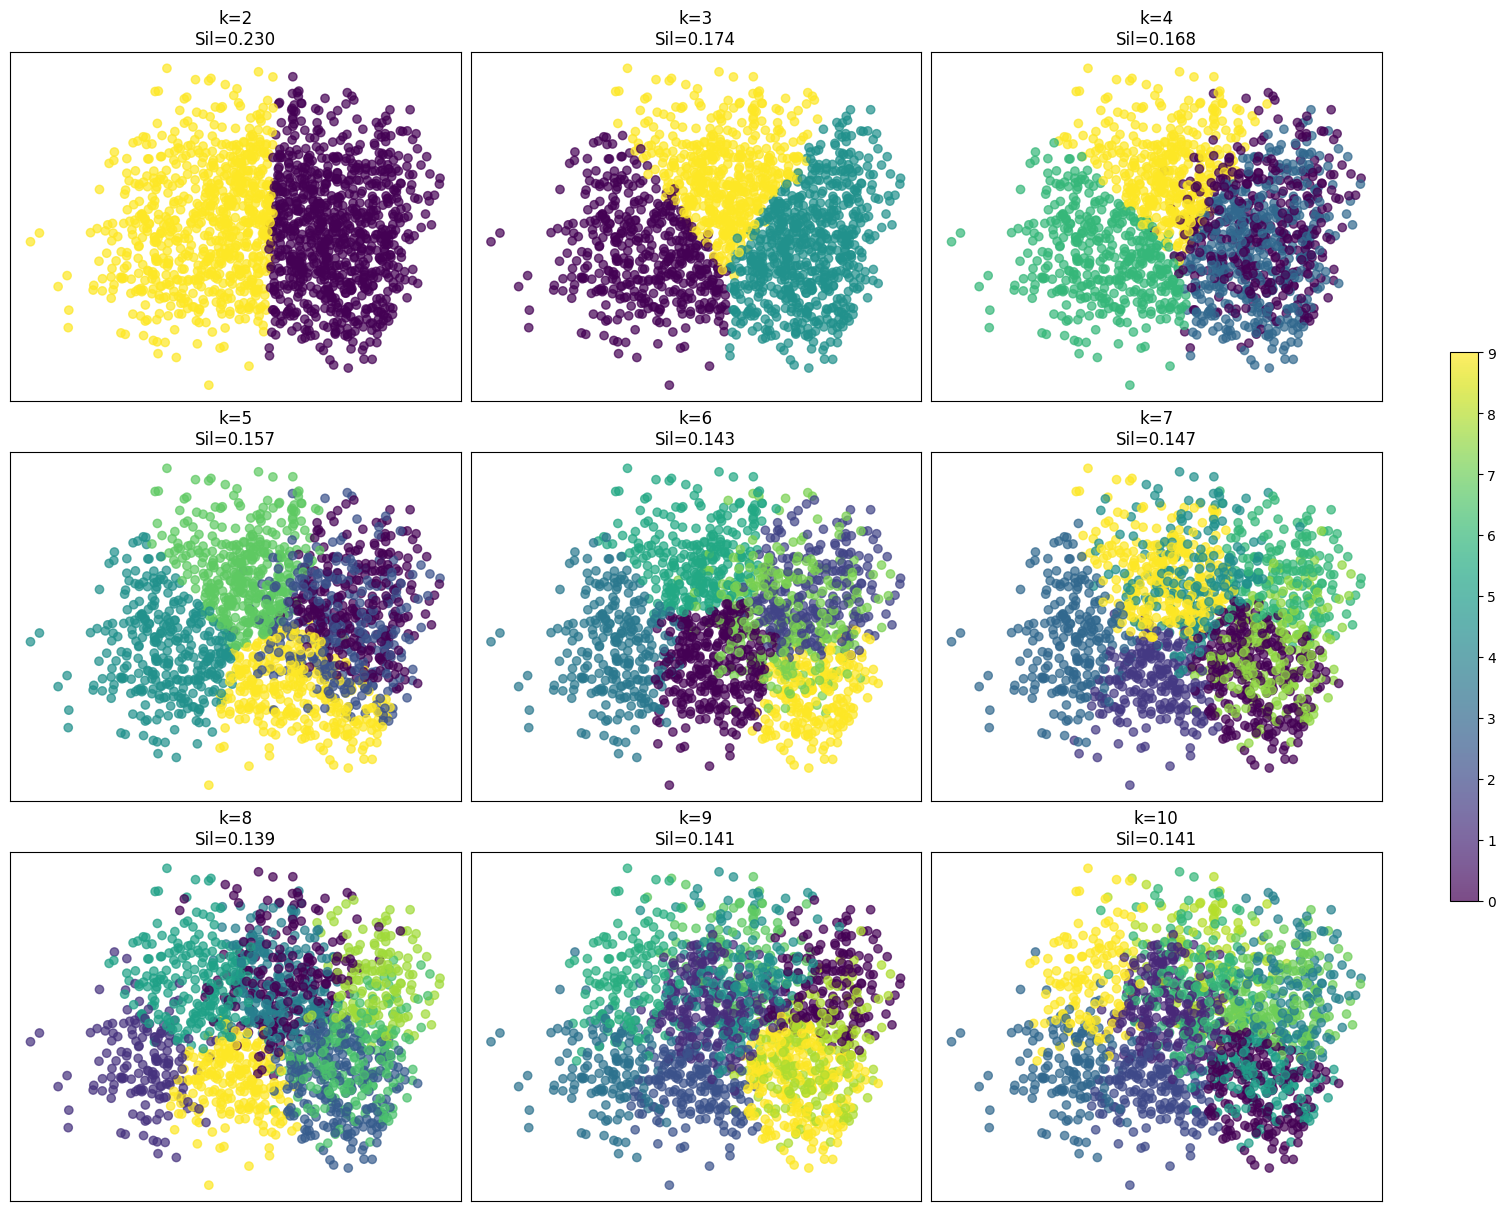

In [19]:
results = []

k_values = range(2, 11)
n_plots = len(k_values)

# Create grid (3x3 for 9 plots)
fig, axes = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True)
axes = axes.flatten()

for idx, k in enumerate(k_values):
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, labels)
    
    results.append({
        "k": k,
        "silhouette_score": sil_score,
        "inertia": kmeans.inertia_
    })
    
    # Plot on subplot
    scatter = axes[idx].scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        cmap="viridis",
        alpha=0.7
    )
    
    axes[idx].set_title(f"k={k}\nSil={sil_score:.3f}")
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])

fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.02)
plt.show()

Both PCA visualizations and silhouette metrics suggest limited intrinsic cluster structure in the data. The PCA projections show substantial overlap among cluster assignments, with no clearly defined boundaries between groups. Additionally, silhouette scores peak at a modest 0.23 for 
𝑘 = 2 and decrease for larger values of 𝑘, indicating weak separation and cohesion. These findings imply that injury risk and workload characteristics may lie on a continuous spectrum rather than forming sharply defined categorical groupings.

### Elbow Plot - Plotting the Inertia vs. k

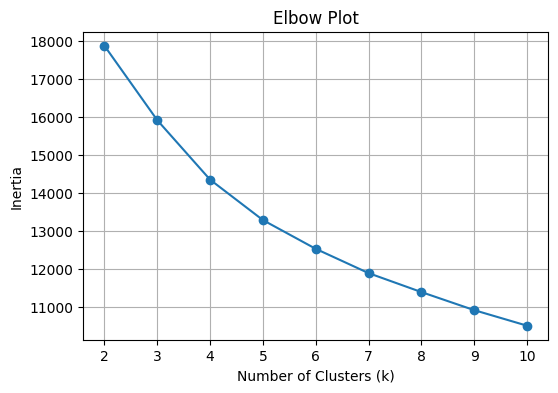

In [20]:
results_df = pd.DataFrame(results)

plt.figure(figsize=(6,4))
plt.plot(results_df["k"], results_df["inertia"], marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Plot")
plt.xticks(results_df["k"])
plt.grid(True)
plt.show()

### Plotting Sihouette Score vs. k

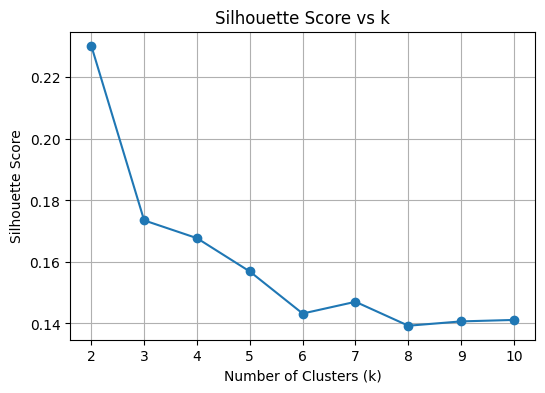

In [21]:
plt.figure(figsize=(6,4))
plt.plot(results_df["k"], results_df["silhouette_score"], marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.xticks(results_df["k"])
plt.grid(True)
plt.show()

The elbow plot and silhouette score plot further reinforce the conclusion that the dataset exhibits weak cluster structure. In the elbow plot, the inertia decreases gradually without a clear inflection point, indicating the absence of a well-defined “elbow” and no obvious optimal value of k. Similarly, the silhouette scores peak at k = 2, but the maximum value of 0.23 is relatively low. This suggests that even at the best-performing cluster count, the separation between clusters is weak and there is substantial overlap among data points.

## 6.3 Hierarchical Clustering + Visualizations

Compute Linkage Matrix

In [22]:
Z = linkage(X_scaled, method="ward")

Plot Dendrogram from Linkage Matrix

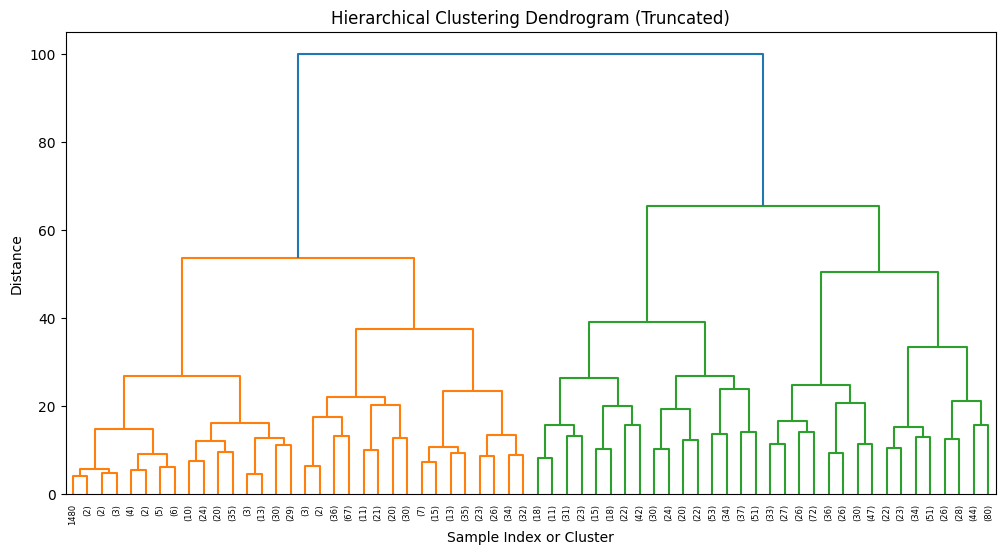

In [23]:
plt.figure(figsize=(12,6))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Sample Index or Cluster")
plt.ylabel("Distance")
plt.show()

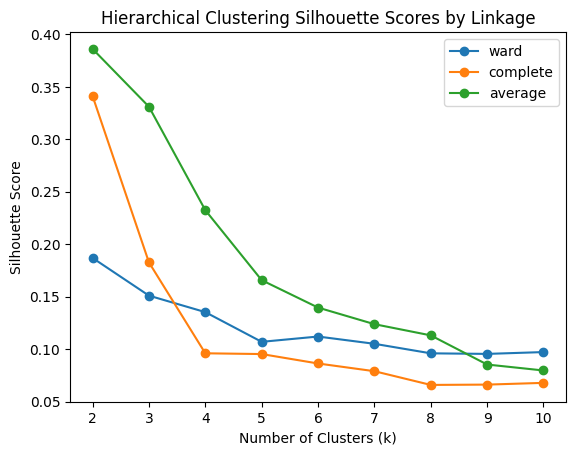

In [26]:
linkages = ["ward", "complete", "average"]
k_values = range(2, 11)

results = []

for linkage in linkages:
    for k in k_values:
        model = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage
        )
        labels = model.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        
        results.append({
            "linkage": linkage,
            "k": k,
            "silhouette": score
        })

results_df = pd.DataFrame(results)

plt.figure()

for linkage in linkages:
    subset = results_df[results_df["linkage"] == linkage]
    
    plt.plot(
        subset["k"], 
        subset["silhouette"], 
        marker="o",
        label=linkage
    )

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Hierarchical Clustering Silhouette Scores by Linkage")
plt.xticks(range(2, 11))
plt.legend()
plt.show()

Similarly to K-means clustering, at k=2 the silhouette scores peak but at a maximum value of around 0.185 which is lower than the score from K-means. Low scores close to zero also suggest that the separation between clusters is weak and there is a substantial overlap amongst clusters.

Based on the results of both K-means and Hierarchal clustering, the current dataset and features suggest that players cannot be easily nauturally clustered together. Instead, the injury-related features appear to vary along a continuum rather than forming discrete archetypes than we originally thought

In [ ]:
# === Cluster Profiling: What do the 2 clusters look like? ===
kmeans_best = KMeans(n_clusters=2, random_state=42, n_init=20)
train_df['cluster'] = kmeans_best.fit_predict(X_scaled)

# Mean feature values per cluster
feature_cols = [c for c in train_df.columns if c not in ['target_next_season', 'cluster']]
profile = train_df.groupby('cluster')[feature_cols].mean().T
profile.columns = ['Cluster 0', 'Cluster 1']
profile['Difference'] = profile['Cluster 1'] - profile['Cluster 0']

print(f"Cluster sizes: {train_df['cluster'].value_counts().to_dict()}")
print(f"\n--- Cluster Profiles (Mean Feature Values) ---")
profile.round(2)

Cluster sizes: {0: 880, 1: 740}

--- Cluster Profiles (Mean Feature Values) ---


,Cluster 0,Cluster 1,Difference
min,28.48,13.83,-14.65
gp,69.17,46.67,-22.50
dist_miles,1.98,0.99,-0.99
usg_pct,0.20,0.17,-0.04
ts_pct,0.55,0.51,-0.03
age,27.47,25.64,-1.83
player_height_inches,78.94,79.17,0.23
player_weight,221.73,219.10,-2.63
injured_last_season,0.42,0.17,-0.25
injury_report_count_last_season,0.93,0.34,-0.59


Height/weight/b2b are basically identical between clusters so the split is driven by workload and injury history. Let's find out if high-usage cluster actually get injured more?

In [ ]:
# === Do clusters differ in actual injury outcomes? ===
injury_by_cluster = train_df.groupby('cluster')['target_next_season'].agg(['mean', 'median', 'std', 'count'])
injury_by_cluster.columns = ['Mean Injuries', 'Median Injuries', 'Std', 'Count']
print("--- Injury Outcomes by Cluster ---")
print(injury_by_cluster.round(3))

pct_injured = train_df.groupby('cluster')['target_next_season'].apply(lambda x: (x > 0).mean())
print(f"\n% of players with at least 1 injury report:")
print(f"  Cluster 0 (high-usage): {pct_injured[0]:.1%}")
print(f"  Cluster 1 (low-usage):  {pct_injured[1]:.1%}")

--- Injury Outcomes by Cluster ---
         Mean Injuries  Median Injuries    Std  Count
cluster                                              
0                1.775              1.0  1.677    880
1                0.982              1.0  1.272    740

% of players with at least 1 injury report:
  Cluster 0 (high-usage): 72.4%
  Cluster 1 (low-usage):  51.8%


In [ ]:
# === Sensitivity Analysis: Linkage Method Comparison ===
linkage_methods = ['ward', 'complete', 'average']
sensitivity_results = []

for method in linkage_methods:
    for k in [2, 3, 4]:
        model = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        sensitivity_results.append({'Linkage': method, 'k': k, 'Silhouette': round(sil, 3)})

sensitivity_df = pd.DataFrame(sensitivity_results).pivot(index='Linkage', columns='k', values='Silhouette')
print("--- Hierarchical Clustering: Sensitivity to Linkage Method ---")
print(sensitivity_df)

--- Hierarchical Clustering: Sensitivity to Linkage Method ---
k             2      3      4
Linkage                      
average   0.386  0.331  0.232
complete  0.341  0.183  0.096
ward      0.187  0.151  0.135


## 6.4 Identifying Potential Outliers from Clustering Results

Although the unsupervised learning results indicate that there is no strong natural clustering structure in the player data based on the selected features, the clustering analysis can still be useful for identifying potential outliers. Specifically, it may highlight players who exhibit unusually high or low injury risk profiles relative to the broader population.

In [ ]:
# === Outlier Detection: Identify unusual player profiles ===
distances = np.linalg.norm(
    X_scaled - kmeans_best.cluster_centers_[train_df['cluster'].values], 
    axis=1
)

train_df['distance_to_centroid'] = distances
threshold = np.percentile(distances, 97)
outliers = train_df[train_df['distance_to_centroid'] > threshold].copy()

# Label archetypes
outliers['archetype'] = outliers['cluster'].map({0: 'High-usage', 1: 'Low-usage'})

print(f"Outlier threshold (97th percentile): {threshold:.2f}")
print(f"Number of outliers: {len(outliers)}\n")

outlier_display = outliers[['archetype', 'min', 'gp', 'age', 'player_weight',
                            'injury_report_count_last_season', 'target_next_season', 
                            'distance_to_centroid']].sort_values('distance_to_centroid', ascending=False)
print("--- Top 10 Outlier Profiles ---")
outlier_display.head(10)

Outlier threshold (97th percentile): 5.06
Number of outliers: 49

--- Top 10 Outlier Profiles ---


,archetype,min,gp,age,player_weight,injury_report_count_last_season,target_next_season,distance_to_centroid
1616,Low-usage,0.8,1,24.0,215.0,0.0,0,8.859159
1480,Low-usage,3.1,3,23.0,185.0,2.0,0,8.844240
1481,Low-usage,2.0,3,22.0,230.0,0.0,1,8.780441
1301,Low-usage,5.5,1,26.0,186.0,0.0,0,8.445317
1297,Low-usage,3.9,2,24.0,185.0,0.0,2,8.172258
1417,Low-usage,0.7,3,23.0,218.0,0.0,1,7.928334
940,Low-usage,1.4,1,26.0,209.0,0.0,0,7.826063
1519,Low-usage,6.1,1,24.0,250.0,0.0,0,7.579531
1311,Low-usage,3.4,2,24.0,204.0,0.0,0,7.209519
559,High-usage,17.0,75,29.0,230.0,8.0,2,6.882171


Most outliers are low-usage players with extremely limited playing time (1–6 games) 
who don't fit either archetype well. These are probably players who were injured early, 
called up briefly from the G-League, or signed late-season contracts. Their atypical 
profiles make them poor candidates for either cluster, not really defining either of the two main archetypes.

## 6.5 Summary

**Best method:** KMeans (k=2, silhouette: 0.230). Hierarchical with average linkage performed better (0.386) in sensitivity analysis.

**Two player archetypes identified:**

- **Cluster 0 — High-usage starters** (880 players): 28.5 min/game, 69 GP, 72.4% injury rate

- **Cluster 1 — Low-usage role players** (740 players): 13.8 min/game, 47 GP, 51.8% injury rate

**Key findings:**

- Clusters are primarily separated by workload (minutes, games played) and injury history — not body type

- High-usage players have 1.8x the mean injury reports (1.78 vs 0.98) and higher injury prevalence (72.4% vs 51.8%)

- This aligns with supervised learning, where `age_x_minutes` and injury history were the top predictors

- PCA captures 55.1% of variance in 2 components meaning clusters may have more separation in full feature space

- Linkage method significantly affects hierarchical results (average: 0.386 vs ward: 0.187 at k=2)

- 49 outliers identified (3%) which was mostly low-GP players with atypical profiles

**Connection to supervised learning:** Both analyses converge on the same insight: workload and injury history are the dominant factors in NBA injury risk, but the signal exists on a continuum rather than in discrete categories.